# Pandas + Seaborn 분석 리포트

## 데이터 전처리

### 데이터 호출

In [1]:
import pandas as pd

In [2]:
# CSV 데이터 불러오기
data = pd.read_csv("reviews.csv")
data

,review_id,product_id,category,review_text,review_length,num_words,sentiment_score,rating
0,R0001,P158,home,Amazing quality and fast shipping.,134,27,-0.60,3
1,R0002,P117,fashion,"Just okay, nothing special.",115,28,-0.10,5
2,R0003,P160,fashion,Not worth the money.,139,32,0.20,5
3,R0004,P127,fashion,"Just okay, nothing special.",165,32,0.22,4
4,R0005,P151,home,"Just okay, nothing special.",112,15,-0.03,4
...,...,...,...,...,...,...,...,...
195,R0196,P193,electronics,Amazing quality and fast shipping.,131,21,-0.06,5
196,R0197,P153,sports,Not worth the money.,93,13,0.07,5
197,R0198,P169,sports,"Excellent product, I loved it!",124,34,-0.29,3
198,R0199,P156,sports,"Just okay, nothing special.",121,24,-0.02,1


### 결측치 확인 및 제거

In [3]:
# 컬럼별 결측치 개수 확인
data.isnull().sum()

review_id          0
product_id         0
category           0
review_text        5
review_length      0
num_words          0
sentiment_score    5
rating             0
dtype: int64

In [4]:
# 결측치가 존재하는 행 확인
data[data.isnull().any(axis=1)]

,review_id,product_id,category,review_text,review_length,num_words,sentiment_score,rating
20,R0021,P111,home,NaN,163,41,1.00,5
26,R0027,P199,fashion,NaN,85,25,-0.28,4
50,R0051,P108,sports,NaN,129,16,0.17,3
102,R0103,P199,electronics,"Just okay, nothing special.",109,30,NaN,1
123,R0124,P141,sports,NaN,77,39,0.49,1
131,R0132,P143,sports,"Terrible experience, would not buy again.",122,18,NaN,3
134,R0135,P106,fashion,Not worth the money.,92,31,NaN,4
155,R0156,P153,fashion,"Just okay, nothing special.",98,17,NaN,5
162,R0163,P198,electronics,"Terrible experience, would not buy again.",154,24,NaN,2
174,R0175,P163,fashion,NaN,128,40,0.61,4


In [5]:
 # 결측치 제거
 # 결측치가 존재하는 행이 전체 데이터의 5%이므로 해당 행을 제거한다.
data = data.dropna()
data.reset_index(drop=True)

,review_id,product_id,category,review_text,review_length,num_words,sentiment_score,rating
0,R0001,P158,home,Amazing quality and fast shipping.,134,27,-0.60,3
1,R0002,P117,fashion,"Just okay, nothing special.",115,28,-0.10,5
2,R0003,P160,fashion,Not worth the money.,139,32,0.20,5
3,R0004,P127,fashion,"Just okay, nothing special.",165,32,0.22,4
4,R0005,P151,home,"Just okay, nothing special.",112,15,-0.03,4
...,...,...,...,...,...,...,...,...
185,R0196,P193,electronics,Amazing quality and fast shipping.,131,21,-0.06,5
186,R0197,P153,sports,Not worth the money.,93,13,0.07,5
187,R0198,P169,sports,"Excellent product, I loved it!",124,34,-0.29,3
188,R0199,P156,sports,"Just okay, nothing special.",121,24,-0.02,1


### 분포 시각화 및 이상치 탐지

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

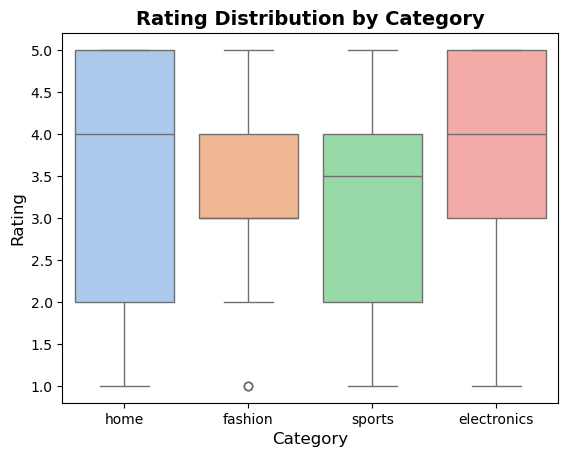

In [7]:
sns.boxplot(data=data, x='category', y='rating', hue='category', palette='pastel', legend=False)

plt.title("Rating Distribution by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

In [8]:
# 이상치 확인
data[(data['category']=='fashion') & (data['rating']==1)]

,review_id,product_id,category,review_text,review_length,num_words,sentiment_score,rating
70,R0071,P164,fashion,"Just okay, nothing special.",130,35,0.06,1
122,R0123,P132,fashion,"Terrible experience, would not buy again.",162,19,-0.13,1
169,R0170,P103,fashion,"Just okay, nothing special.",97,19,0.02,1


## 기술 통계 및 시각화

### 기술 통계 요약

In [9]:
data.describe()

,review_length,num_words,sentiment_score,rating
count,190.000000,190.000000,190.000000,190.000000
mean,118.378947,24.921053,0.147632,3.515789
std,27.927032,6.747061,0.472050,1.262928
min,41.000000,2.000000,-1.000000,1.000000
25%,99.000000,20.000000,-0.195000,3.000000
50%,119.500000,25.000000,0.165000,4.000000
75%,134.750000,29.000000,0.477500,4.750000
max,201.000000,51.000000,1.000000,5.000000


### category별 감정 점수/평균 평점 시각화

In [10]:
# 카테고리별 감성 점수 평균 계산
avg_sentiment_by_category = data.groupby('category')['sentiment_score'].mean().reset_index()
avg_sentiment_by_category

,category,sentiment_score
0,electronics,0.129804
1,fashion,0.165102
2,home,0.069375
3,sports,0.238333


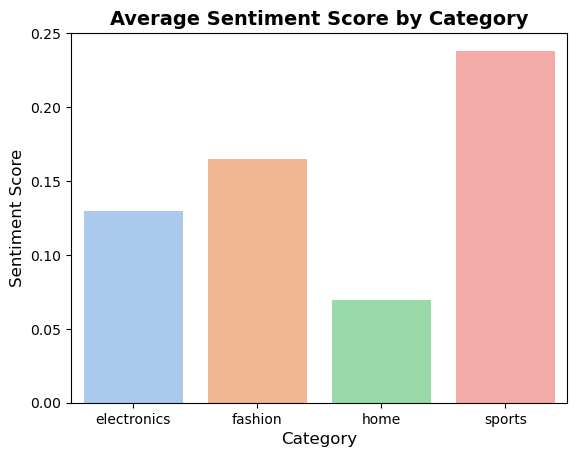

In [11]:
sns.barplot(avg_sentiment_by_category, x='category', y='sentiment_score', hue='category', palette='pastel', legend=False)

plt.title("Average Sentiment Score by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Sentiment Score", fontsize=12)

plt.show()


In [12]:
# 카테고리별 평점 평균 계산
avg_rating_by_category = data.groupby('category')['rating'].mean().reset_index()
avg_rating_by_category

,category,rating
0,electronics,3.764706
1,fashion,3.469388
2,home,3.500000
3,sports,3.285714


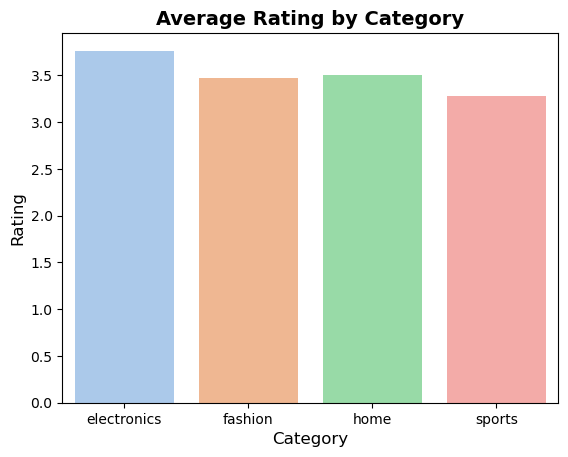

In [13]:
sns.barplot(avg_rating_by_category, x='category', y='rating', hue='category', palette='pastel', legend=False)

plt.title("Average Rating by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()


### 평점과 감정 점수의 관계 시각화

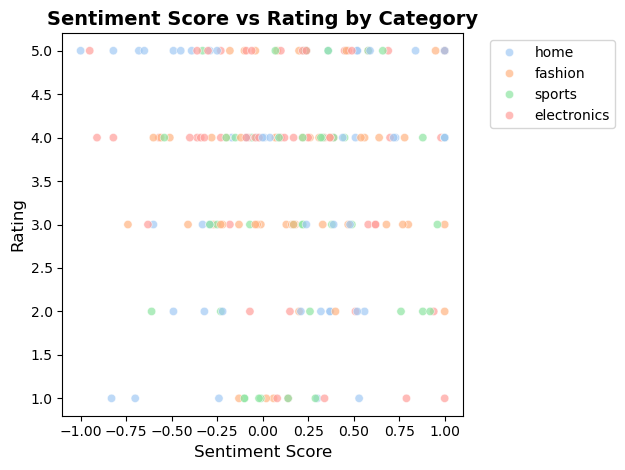

In [14]:
sns.scatterplot(data=data, x='sentiment_score', y='rating', hue='category', palette='pastel', alpha=0.7)

plt.title("Sentiment Score vs Rating by Category", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Score", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

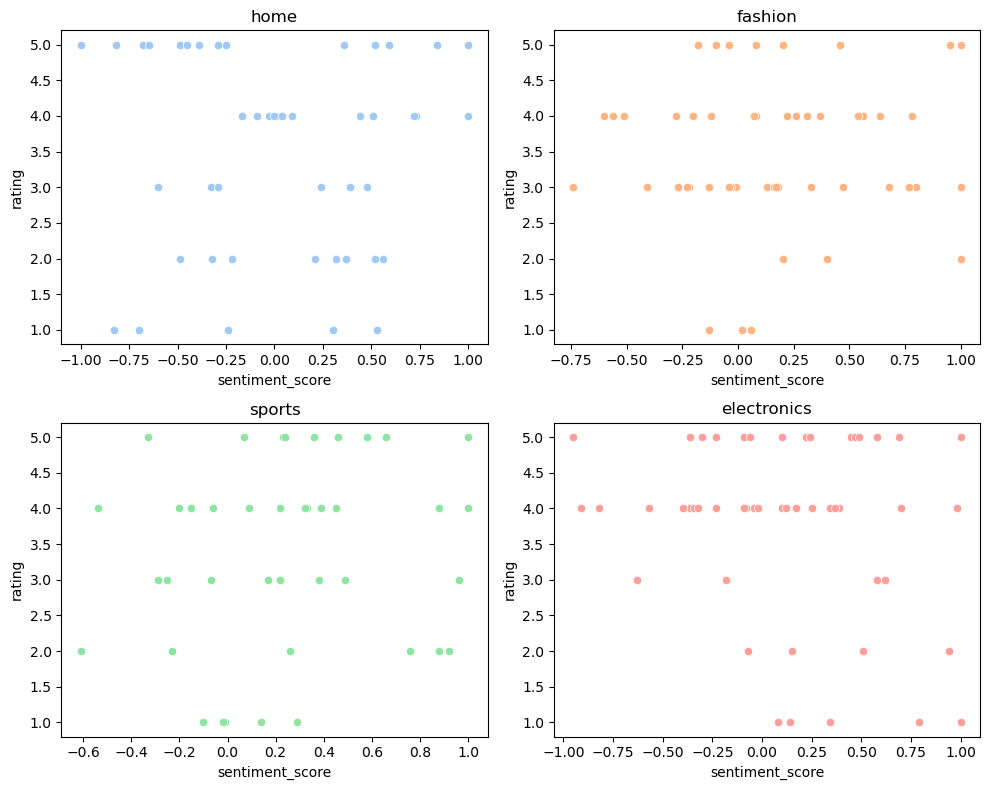

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.scatterplot(data=data[data['category'] == 'home'], x='sentiment_score', y='rating', color=sns.color_palette('pastel')[0], ax=axes[0, 0])
axes[0, 0].set_title('home')

sns.scatterplot(data=data[data['category'] == 'fashion'], x='sentiment_score', y='rating', color=sns.color_palette('pastel')[1], ax=axes[0, 1])
axes[0, 1].set_title('fashion')

sns.scatterplot(data=data[data['category'] == 'sports'], x='sentiment_score', y='rating', color=sns.color_palette('pastel')[2], ax=axes[1, 0])
axes[1, 0].set_title('sports')

sns.scatterplot(data=data[data['category'] == 'electronics'], x='sentiment_score', y='rating', color=sns.color_palette('pastel')[3], ax=axes[1, 1])
axes[1, 1].set_title('electronics')

plt.tight_layout()

plt.show()


### 텍스트 길이와 평점의 관계 시각화

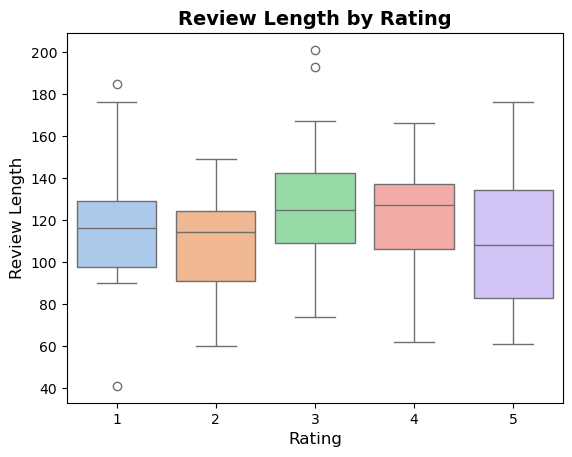

In [16]:
sns.boxplot(data=data, x='rating', y='review_length', hue='rating', palette='pastel', legend=False)

plt.title("Review Length by Rating", fontsize=14, fontweight='bold')
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Review Length", fontsize=12)

plt.show()

### 텍스트 길이와 감정 점수의 관계 시각화

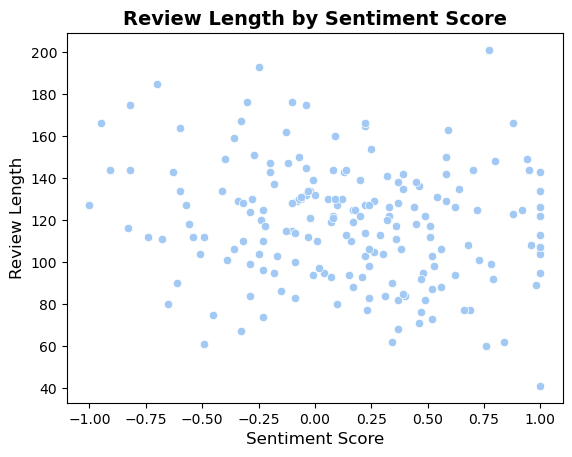

In [17]:
sns.scatterplot(data=data, x='sentiment_score', y='review_length', color=sns.color_palette("pastel")[0])

plt.title("Review Length by Sentiment Score", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Score", fontsize=12)
plt.ylabel("Review Length", fontsize=12)

plt.show()

In [18]:
corr = data["sentiment_score"].corr(data["review_length"])
print(f"Correlation between sentiment_score and review_length: {corr}")

Correlation between sentiment_score and review_length: -0.18522787855103365


## AI 분석을 위한 인사이트 도출

### 1. sentiment_score가 높을수록 평점이 높은가?

sentiment_score와 무관하게 rating은 전반적으로 골고루 분포되어 있으며, 양의 상관 관계를 보이지 않는다.

따라서 sentiment_score가 높을수록 rating이 높다고 할 수 없다.


### 2. review_length와 sentiment_score 사이에 유의미한 관계가 있는가?

sentiment_score와 review_length 사이의 산점도를 확인한 결과, 뚜렷한 상관관계가 보이지 않는다.

또한, 두 변수 사이의 correlation을 계산한 결과는 약 -0.19로 수치상으로도 유의미한 상관관계가 있다고 할 수 없다.

따라서 review_length와 sentiment_score 사이에 유의미한 관계가 있다고 할 수 없다.

### 3. category별 감성 점수 평균에 차이가 존재하는가?

sentiment_score는 -1~1의 값을 가지며, home, fashion, sports, electronics의 평균 sentiment_score는 각각 0.07, 0.17, 0.24, 0.13이다.

min과 max는 0.07과 0.24로, 그 차는 0.17이다.

따라서 category별 sentiment_score는 큰 차이를 보이지 않는다.
